<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/01_pytorch_Workflow_ch_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pytorch Workflow

In [1]:
what_were_covering = {1:"data (prepare and load)",
                      2:"build model",
                      3:"fitting the model to data (training)",
                      4:"making predictions and evaluating a model (inference)",
                      5:"saving and loading a model",
                      6:"putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn #nn contains all the Pytorch's building blocks
import matplotlib.pyplot as plt

torch.__version__

'2.6.0+cu124'

##1. Data preparing and loading

data can be almost anything


machine is a game of two parts
1. get data into a numerical representation.
2. build a model to learn patterns in that numerical representation.

To showcase this , let's create some known data using the linear regression.

we'll use a linear regression formula to make a straight line with known parameters.


In [3]:
#create *known* parameters
weight =0.7
bias = 0.3

#create
start =0
end =1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X),len(y)

(50, 50)

#splitting data into test and training data

let's create test and training data from our data

In [5]:
train_split = int(0.8 * len(X))
x_train,y_train = X[:train_split],y[:train_split]

x_test, y_test = X[train_split:],y[train_split:]

len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

In [6]:
x_train,y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

##visualizing data

In [12]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):
  """
  plots taining data , test data , and compare predictions
  """
  plt.figure(figsize=(10,7))

  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4, label="Training data")
  #plot testing data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="testing data")

  # are they predictions?
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4, label="predictions")

  plt.legend(prop={"size":14});


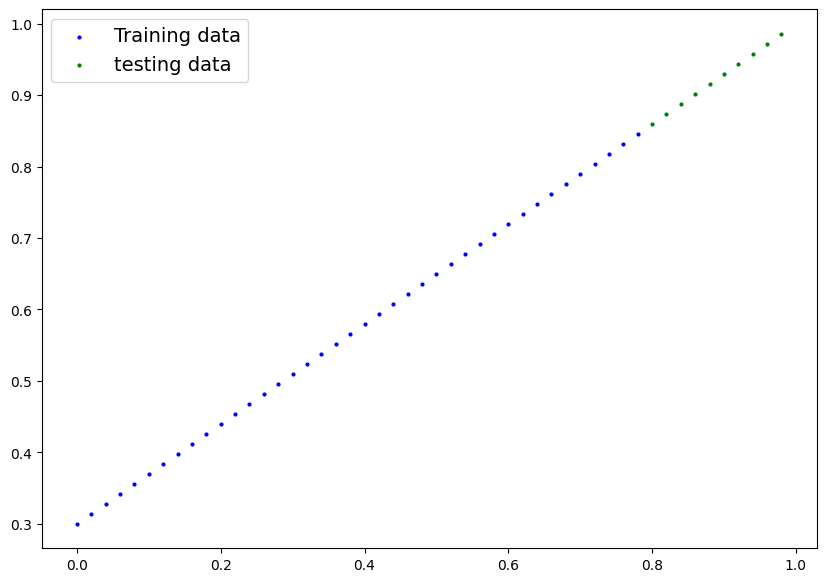

In [8]:
plot_predictions();


## 2. building first pytorch model

What our model does:


*   start with random values (weights and bias),
*   look at training data  and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so:
1. gradient descent
2. backpropagation


In [9]:
#create a linear regression model class

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype = torch.float))
    #forward method to define the computation in the model
  def forward(self,x: torch.Tensor)-> torch.Tensor: # x is input data
    return self.weights * x + self.bias

##Pytorch model building essentials

*   torch.nn - contains all of the buildings for computational graphs(a neural network can be considered a computational graph)
*   torch.nn.Parameter - what parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us
*   torch.nn.Module - the base class for all neural network modules, if you subclass it, you should overwrite forward()
*   torch.optim - this where the optimizers in pytorch live , they will help with gradient descent,
* def forward() - All nn modules subclasses require you to overwrite forward(), this method defines what happens in the forward computation.





### checking the content of our pytorch model

Now we have created a model, let's see what's inside...

check our models parameters

In [10]:
#create a random seed
torch.manual_seed(42)

#create an instance of the model (this is subclass of nn.module)
model_O = LinearRegressionModel()


#check out the parameters of the function
list(model_O.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
#list named parameters
model_O.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [12]:
weight,bias

(0.7, 0.3)

### Making prediction using `torch.inference_mode()`

To check our models prediction power, let's see how weel it predicts `y_test` based on `x_test`.

when we pass data through our model, it's going to run through the `forward()` method

In [13]:
x_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [14]:
with torch.inference_mode():
  y_preds = model_O(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [15]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

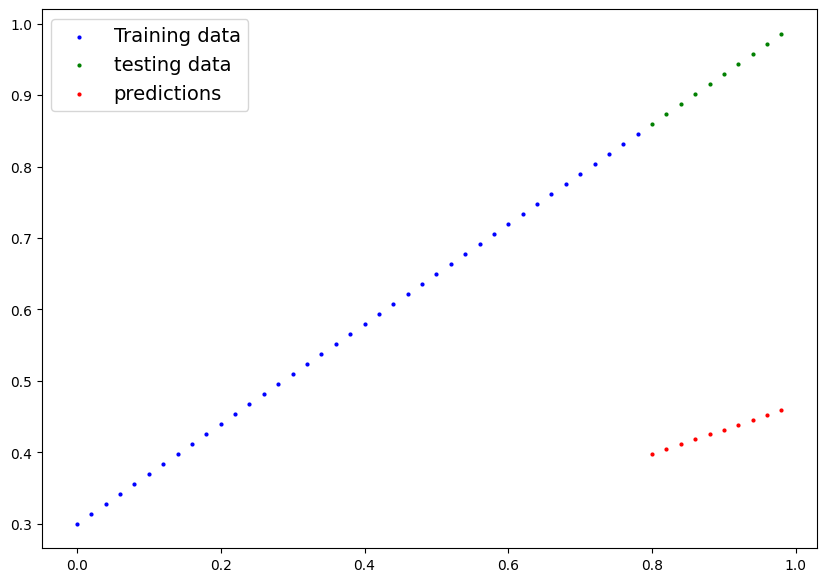

In [16]:
plot_predictions(predictions=y_preds)

### Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.and

Or in other words from a poor representation of the data to a better representation of the data.

use a loss function to know

use a optimizer to improve model

In [17]:
list(model_O.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [18]:
model_O.state_dict()
#check out model parameters (a parameter is a vlaue that the model sets itself)

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [19]:
# Setup a loss function

loss_fn = nn.L1Loss()

#setup an optimizre
optimizer = torch.optim.SGD(model_O.parameters(),
                            lr=0.01) #lr=>learnig rate
#

In [20]:
list(model_O.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

###Building a training loop in PyTorch

A couple of things we need in a training loop:
0. loop throught the data.
1. forward pass (this involves data moving through the `forward()` function) to make predictions on propagation.
2. Calculate the loss (compare forward pass predictions to ground truth table)
3. Optimizer sero grad.
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss **back propagation**.
5. Optimizer step - use the optimizer to adjust our models parameters to try and improve the loss (**gradient descent**)

In [21]:
#an epoch is one loop through the data (this is a hyper parameter because we set it ourselves.., )
epochs =200
#tracking different values
epoch_count =[]
loss_values=[]
test_loss_values=[]
###Training
#0. loop throught the data
for epoch in range(epochs):
  #set teh model to training mode.
  model_O.train() # train mode in pytorch sets all parameters that require gradients to require the gradient.

  #1. Forward pass
  y_preds= model_O(x_train)

  #2. calculate the loss
  loss=loss_fn(y_preds,y_train)

  #3. optimizer zero grad
  optimizer.zero_grad()

  #4. Perform backpropagation with respect to the parameters of the model
  loss.backward()

  #5.  step up the optimizer (gradient descent performing)
  optimizer.step()

##Testing
  model_O.eval() #turns off gradient tracking

  with torch.inference_mode(): # turns off gradient traacking and a couple of more things
    #1. forward paSS
    test_preds = model_O(x_test)

    #2. calculate the loss
    test_loss =loss_fn(test_preds,y_test)
  if epoch %10==0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch:{epoch} | loss :{loss} | test loss: {test_loss}")

    print(model_O.state_dict())




Epoch:0 | loss :0.31288138031959534 | test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch:10 | loss :0.1976713240146637 | test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Epoch:20 | loss :0.08908725529909134 | test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Epoch:30 | loss :0.053148526698350906 | test loss: 0.14464017748832703
OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])
Epoch:40 | loss :0.04543796554207802 | test loss: 0.11360953003168106
OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])
Epoch:50 | loss :0.04167863354086876 | test loss: 0.09919948130846024
OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])
Epoch:60 | loss :0.03818932920694351 | test loss: 0.08886633068323135
OrderedDict([('weights', tensor([0.5116])), ('bias', tensor([0.3788]))])
E

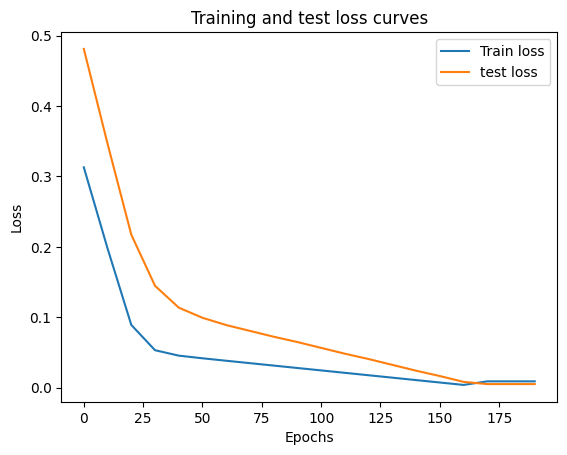

In [22]:
#plot the loss curv
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="Train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [23]:
model_O.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [24]:
torch.manual_seed(42)
epochs =100
for epoch in range (epochs):
  model_O.train()
  y_preds=model_O(x_train) #forward
  loss = loss_fn(y_preds,y_train)#loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
print(f"Loss : {loss}")
list(model_O.parameters())

Loss : 0.0025885067880153656


[Parameter containing:
 tensor([0.6990], requires_grad=True),
 Parameter containing:
 tensor([0.3093], requires_grad=True)]

In [25]:
model_O.state_dict( )

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [26]:
with torch.inference_mode():
  y_preds_new = model_O(x_test)

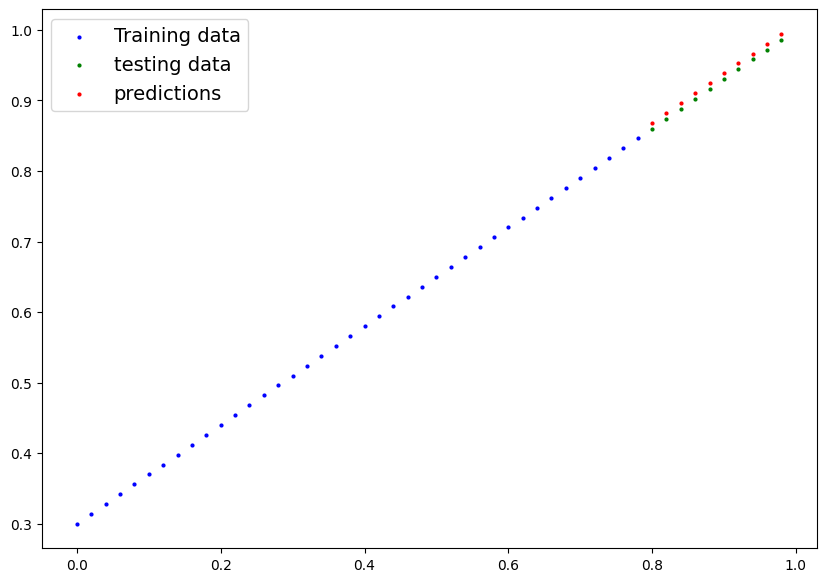

In [27]:
plot_predictions(predictions=y_preds_new)

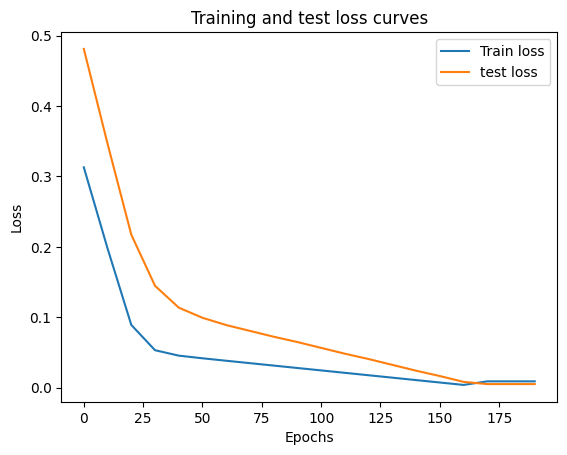

In [28]:
#plot the loss curv
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="Train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

###Saving a model in pytorch

There are three main methods u should know in pytorch

1. `torch.save()` - allows you save a pytorch object in pythons pickle format.
2. `torch.load()` - allows you to load a saved pytorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a models saved state dictionary.

In [33]:
#saving our pytorch model
from pathlib import Path

#1. create models directory
MODEL_PATH =Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

#saving the model state dict
print(f"saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_O.state_dict(),f=MODEL_SAVE_PATH)

saving model to :models/01_pytorch_workflow_model_0.pth


In [34]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1680 Mar 29 17:27 01_pytorch_workflow_model_0.pth


##loading a pytoch model

Since we saved our models `state_dict`m

In [35]:
model_O.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [37]:
#to load in a saved state_dict we have to instantiate a new instance off our model
loaded_model_O = LinearRegressionModel()

#load the state_dict
loaded_model_O.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [40]:
loaded_model_O.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [41]:
#making some predictions with loaded model
loaded_model_O.eval()
with torch.inference_mode():
  loaded_model_preds=loaded_model_O(x_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [43]:
#comparing loaded model preds with original model preds
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [46]:
with torch.inference_mode():
  y__preds = model_O(x_test)

y__preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [47]:
y__preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

###6. DOING EVERYTHING ONCE AGAIN IN ONE GO

In [3]:
##1. importing libraries require
import torch
from torch import nn
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.6.0+cu124'

###Create device agnostic code

This means if we've got access to a GPU, our code will use it(for potentially faster computing).else

if no GPU is available, our code will use the CPU.

In [13]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

###6.1 DATA

In [14]:
#create data using linear regression formula y=mx+c
weight =0.7
bias =0.3

start=0
end =1
step=0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X +bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [15]:
#split the data
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [16]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):
  """
  plots taining data , test data , and compare predictions
  """
  plt.figure(figsize=(10,7))

  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4, label="Training data")
  #plot testing data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="testing data")

  # are they predictions?
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4, label="predictions")

  plt.legend(prop={"size":14});

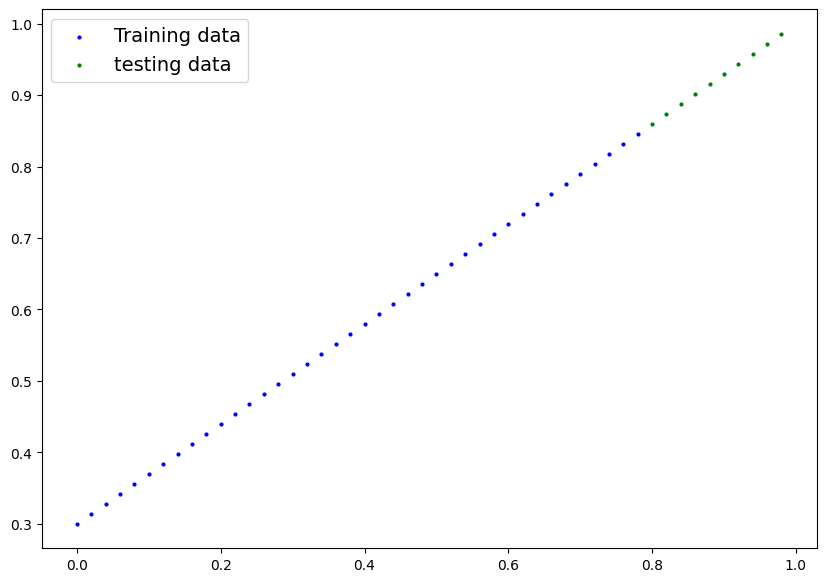

In [17]:
#plot the data
plot_predictions(X_train,y_train,X_test,y_test)

###6.2 Pytorch linear model

In [20]:
#create a linaer model using subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #use nn.Linear() for creating model parameyers
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)

#set the manual seeds
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1,model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [21]:
#check the model curretn device
next(model_1.parameters()).device

device(type='cpu')

In [22]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

###6.3 train model
For training we need
loss function
optimizer
training Loop
testing loop

In [23]:
loss_fn =nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.01)

In [25]:
torch.manual_seed(42)

epochs=200

#put data on target device device agnostic code for data
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range (epochs):
  model_1.train()
  #1 forward pass
  Y_pred = model_1(X_train)

  #2 loss
  loss_val = loss_fn(Y_pred,y_train)

  #3 optimizer
  optimizer.zero_grad()

  #4 back propagation
  loss_val.backward()

  #5 optimizeer
  optimizer.step()


  ###testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred,y_test)

  #print what is happening

  if epoch % 10==0:
    print(f"Epoch:{epoch} | loss : {loss_val} | test_loss:{test_loss}")

Epoch:0 | loss : 0.5551779866218567 | test_loss:0.5739762187004089
Epoch:10 | loss : 0.439968079328537 | test_loss:0.4392664134502411
Epoch:20 | loss : 0.3247582018375397 | test_loss:0.30455657839775085
Epoch:30 | loss : 0.20954833924770355 | test_loss:0.16984669864177704
Epoch:40 | loss : 0.09433845430612564 | test_loss:0.03513690456748009
Epoch:50 | loss : 0.023886388167738914 | test_loss:0.04784907028079033
Epoch:60 | loss : 0.019956795498728752 | test_loss:0.045803118497133255
Epoch:70 | loss : 0.016517987474799156 | test_loss:0.037530567497015
Epoch:80 | loss : 0.013089174404740334 | test_loss:0.02994490973651409
Epoch:90 | loss : 0.009653178043663502 | test_loss:0.02167237363755703
Epoch:100 | loss : 0.006215683650225401 | test_loss:0.014086711220443249
Epoch:110 | loss : 0.00278724217787385 | test_loss:0.005814164876937866
Epoch:120 | loss : 0.0012645035749301314 | test_loss:0.013801801018416882
Epoch:130 | loss : 0.0012645035749301314 | test_loss:0.013801801018416882
Epoch:140 

In [26]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [27]:
weight,bias

(0.7, 0.3)

### 6.4 making nad evaluatinfg predictions



In [29]:
#turn model into evaluation mode
model_1.eval()

#make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

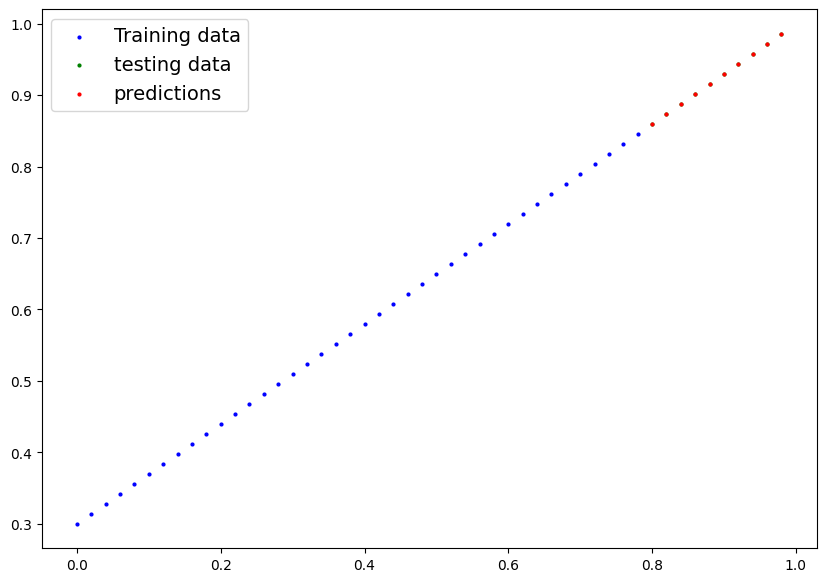

In [32]:
#checking model prediction visually using plot prediction()
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and loading model

In [36]:
from pathlib import Path
#1. create models dicrectory

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

#2. create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3 save model state_dict only
print(f"saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

saving model to :models/01_pytorch_workflow_model_1.pth


In [38]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [39]:
#Load a pytorch model


#create a new instance of linear regression model V2

loaded_model_1 = LinearRegressionModelV2()

#load the saved model_1.state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

#put the model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [40]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [41]:
#evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')